# SAM1 BBox to Polygon (LabelMe)

This notebook runs **SAM1 from Hugging Face** on object tiles using **box + point prompts**, previews random examples, and can export updated LabelMe JSONs with polygon masks.

In [16]:
from pathlib import Path
import json
import random
import shutil
from dataclasses import dataclass

import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch
from tqdm.auto import tqdm

try:
    import cv2
except ImportError as e:
    raise ImportError('This notebook needs opencv-python (`cv2`) for contour->polygon conversion.') from e

from transformers import SamModel, SamProcessor

In [18]:
@dataclass
class Cfg:
    data_dir: Path = Path('data/war_thunder_tank_detection_labelme_pairs_1perc')
    output_dir: Path = Path('data/war_thunder_tank_detection_labelme_pairs_sam1_poly')
    label_name: str = 'Tank'

    model_id: str = 'facebook/sam-vit-base'  # SAM1
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'

    random_seed: int = 42

    # Object-tile crop around bbox center
    tile_size: int = 448
    context_scale: float = 2.0

    # Preview
    preview_samples: int = 6

    # Export controls
    export_limit_records: int = 0  # 0 = all
    overwrite_output: bool = False

cfg = Cfg()
random.seed(cfg.random_seed)
np.random.seed(cfg.random_seed)

print(cfg)

Cfg(data_dir=PosixPath('data/war_thunder_tank_detection_labelme_pairs_1perc'), output_dir=PosixPath('data/war_thunder_tank_detection_labelme_pairs_sam1_poly'), label_name='Tank', model_id='facebook/sam-vit-base', device='cuda', random_seed=42, tile_size=448, context_scale=2.0, preview_samples=6, export_limit_records=0, overwrite_output=False)


In [4]:
def find_image_for_json(data_dir: Path, stem: str):
    exts = ['.png', '.jpg', '.jpeg', '.tif', '.tiff', '.gif']
    for ext in exts:
        p = data_dir / f'{stem}{ext}'
        if p.exists():
            return p
    # fallback: any extension with same stem
    for p in data_dir.glob(f'{stem}.*'):
        if p.is_file() and p.suffix.lower() in exts:
            return p
    return None


def shape_to_bbox(shape):
    pts = shape.get('points', [])
    if len(pts) < 2:
        return None
    xs = [float(p[0]) for p in pts]
    ys = [float(p[1]) for p in pts]
    x0, x1 = min(xs), max(xs)
    y0, y1 = min(ys), max(ys)
    if x1 <= x0 or y1 <= y0:
        return None
    return [x0, y0, x1, y1]


def load_records(data_dir: Path, label_name: str):
    records = []
    json_files = sorted(data_dir.glob('*.json'))
    for jf in tqdm(json_files, desc='Loading LabelMe records'):
        img_path = find_image_for_json(data_dir, jf.stem)
        if img_path is None:
            continue

        d = json.loads(jf.read_text())
        w = int(d.get('imageWidth', 0))
        h = int(d.get('imageHeight', 0))
        if w <= 0 or h <= 0:
            continue

        objects = []
        for si, s in enumerate(d.get('shapes', [])):
            if s.get('label') != label_name:
                continue
            box = shape_to_bbox(s)
            if box is None:
                continue
            x0, y0, x1, y1 = box
            cx = 0.5 * (x0 + x1)
            cy = 0.5 * (y0 + y1)
            objects.append({
                'shape_index': si,
                'bbox_xyxy': [x0, y0, x1, y1],
                'center_xy': [cx, cy],
                'shape_raw': s,
            })

        if len(objects) == 0:
            continue

        records.append({
            'json_path': jf,
            'image_path': img_path,
            'width': w,
            'height': h,
            'objects': objects,
            'json_data': d,
        })
    return records

In [5]:
def compute_object_tile(record, obj, tile_size=448, context_scale=2.0):
    w, h = record['width'], record['height']
    x0, y0, x1, y1 = obj['bbox_xyxy']
    cx, cy = obj['center_xy']

    bw = max(1.0, x1 - x0)
    bh = max(1.0, y1 - y0)
    side = max(tile_size, int(np.ceil(max(bw, bh) * context_scale)))

    left = int(round(cx - side / 2.0))
    top = int(round(cy - side / 2.0))
    left = max(0, min(left, w - side))
    top = max(0, min(top, h - side))
    right = min(w, left + side)
    bottom = min(h, top + side)

    if right - left < 2 or bottom - top < 2:
        return None

    return {
        'crop_xyxy': [left, top, right, bottom],
        'crop_side': right - left,
    }


def to_tile_coords(global_xyxy, crop_xyxy):
    gx0, gy0, gx1, gy1 = global_xyxy
    cx0, cy0, cx1, cy1 = crop_xyxy
    tx0 = gx0 - cx0
    ty0 = gy0 - cy0
    tx1 = gx1 - cx0
    ty1 = gy1 - cy0
    tx0 = max(0.0, min(tx0, cx1 - cx0))
    ty0 = max(0.0, min(ty0, cy1 - cy0))
    tx1 = max(0.0, min(tx1, cx1 - cx0))
    ty1 = max(0.0, min(ty1, cy1 - cy0))
    return [float(tx0), float(ty0), float(tx1), float(ty1)]

In [6]:
def mask_to_polygons(mask_u8, min_area=20.0, epsilon_frac=0.002):
    # mask_u8: uint8 0/1
    m = (mask_u8 > 0).astype(np.uint8)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    polys = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
        peri = cv2.arcLength(cnt, True)
        eps = max(1.0, epsilon_frac * peri)
        approx = cv2.approxPolyDP(cnt, eps, True)
        pts = approx.reshape(-1, 2).astype(float)
        if pts.shape[0] < 3:
            continue
        polys.append([[float(x), float(y)] for x, y in pts])

    return polys

In [19]:
print(f'Loading SAM processor/model: {cfg.model_id}')
processor = SamProcessor.from_pretrained(cfg.model_id)
sam = SamModel.from_pretrained(cfg.model_id).to(cfg.device).eval()
print(f'SAM ready on {cfg.device}')

Loading SAM processor/model: facebook/sam-vit-base


Loading weights: 100%|██████████| 314/314 [00:00<00:00, 1217.34it/s, Materializing param=vision_encoder.pos_embed]                                                 


SAM ready on cuda


In [8]:
def run_sam_on_tile(tile_img_pil, box_xyxy_tile, point_xy_tile):
    inputs = processor(
        images=tile_img_pil,
        input_boxes=[[box_xyxy_tile]],
        input_points=[[[point_xy_tile]]],
        input_labels=[[[1]]],
        return_tensors='pt',
    )
    inputs = {k: v.to(cfg.device) for k, v in inputs.items()}

    with torch.no_grad():
        out = sam(**inputs, multimask_output=True)

    masks = processor.image_processor.post_process_masks(
        out.pred_masks.cpu(),
        inputs['original_sizes'].cpu(),
        inputs['reshaped_input_sizes'].cpu(),
    )

    # masks[0] shape: (num_points=1, num_masks=3, H, W)
    mask_set = masks[0][0].numpy()  # (3,H,W)
    scores = out.iou_scores[0, 0].detach().cpu().numpy()

    best_i = int(np.argmax(scores))
    best_mask = (mask_set[best_i] > 0).astype(np.uint8)

    return {
        'mask_candidates': (mask_set > 0).astype(np.uint8),
        'scores': scores,
        'best_index': best_i,
        'best_mask': best_mask,
    }

In [9]:
records = load_records(cfg.data_dir, cfg.label_name)
n_objs = sum(len(r['objects']) for r in records)
print(f'Records: {len(records)} | objects: {n_objs}')
assert len(records) > 0, 'No valid records found'

Loading LabelMe records: 100%|██████████| 1109/1109 [00:00<00:00, 10557.83it/s]

Records: 1109 | objects: 2905


In [10]:
# Build random object sample list
obj_refs = []
for ri, r in enumerate(records):
    for oi, _ in enumerate(r['objects']):
        obj_refs.append((ri, oi))

random.shuffle(obj_refs)
sample_refs = obj_refs[:cfg.preview_samples]
print(f'Preview samples: {len(sample_refs)}')

Preview samples: 6


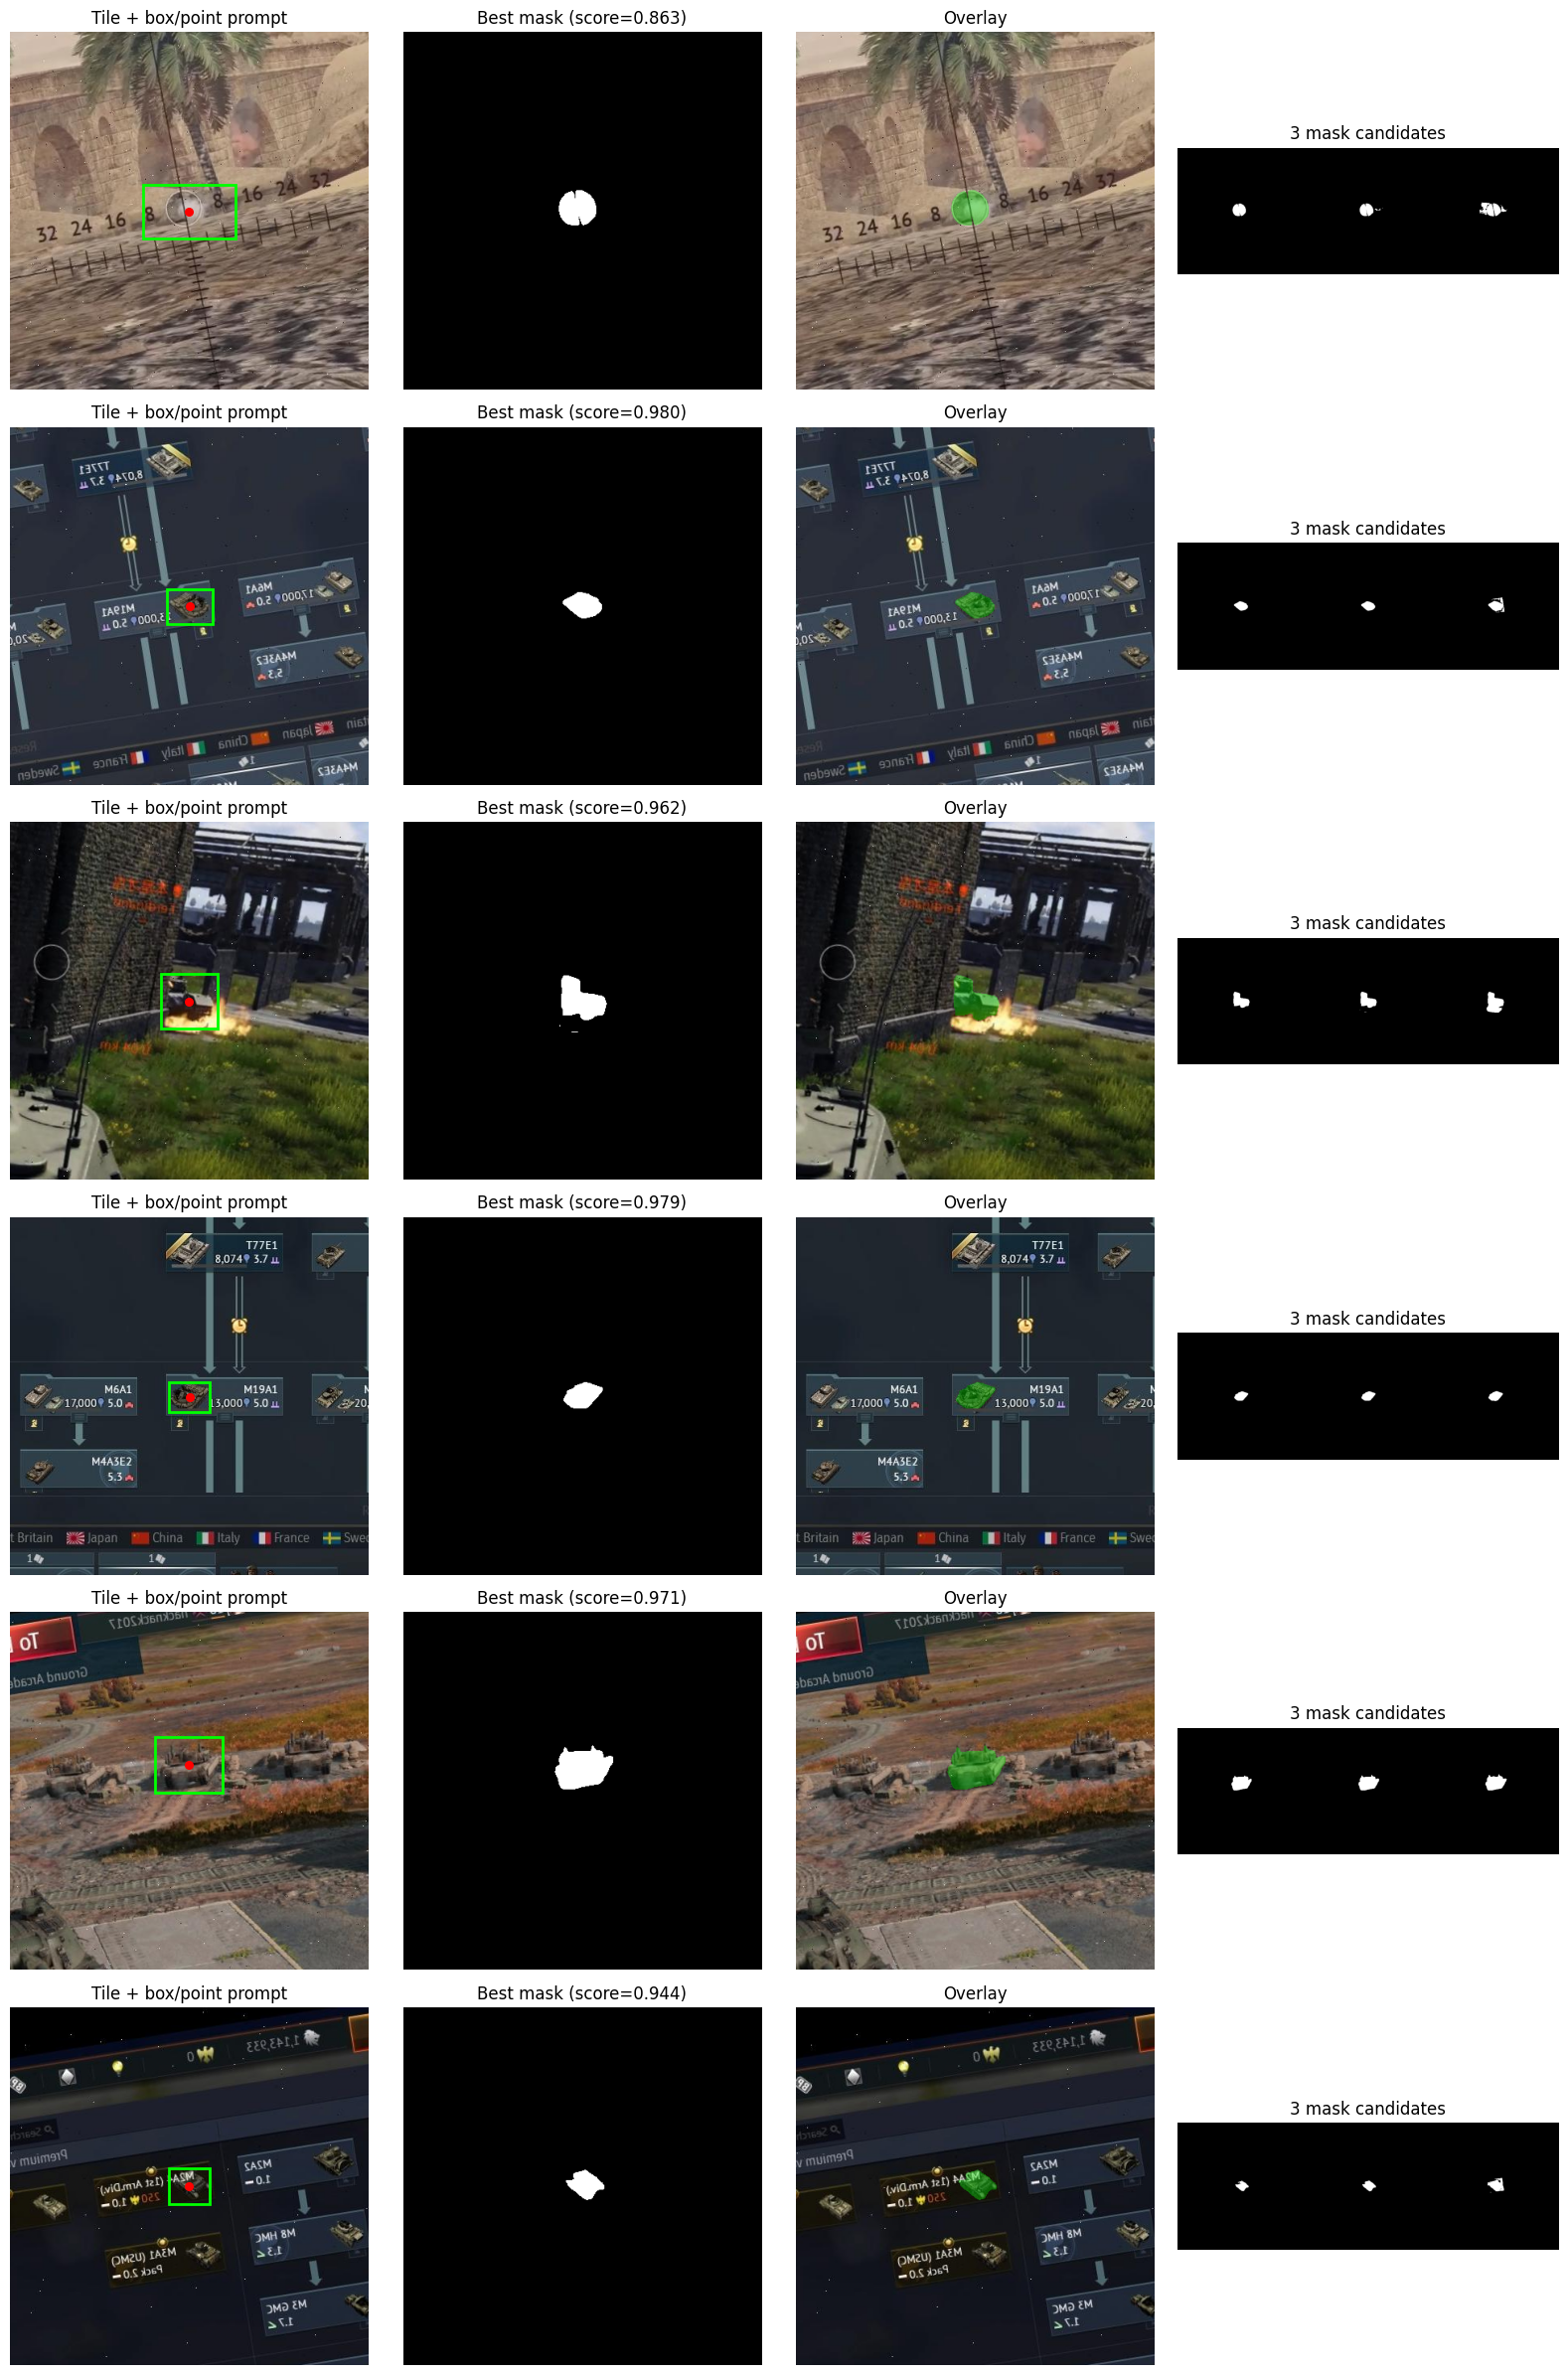

In [11]:
fig, axes = plt.subplots(len(sample_refs), 4, figsize=(16, 4 * max(1, len(sample_refs))))
if len(sample_refs) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, (ri, oi) in enumerate(sample_refs):
    r = records[ri]
    o = r['objects'][oi]

    full = Image.open(r['image_path']).convert('RGB')
    t = compute_object_tile(r, o, tile_size=cfg.tile_size, context_scale=cfg.context_scale)
    if t is None:
        continue
    crop_xyxy = t['crop_xyxy']
    tile = full.crop(tuple(crop_xyxy))

    box_tile = to_tile_coords(o['bbox_xyxy'], crop_xyxy)
    point_tile = [0.5 * (box_tile[0] + box_tile[2]), 0.5 * (box_tile[1] + box_tile[3])]

    pred = run_sam_on_tile(tile, box_tile, point_tile)

    tile_np = np.array(tile)
    best_mask = pred['best_mask']

    # Panel 0: tile + prompts
    axes[row, 0].imshow(tile_np)
    x0, y0, x1, y1 = box_tile
    axes[row, 0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='lime', linewidth=2))
    axes[row, 0].scatter([point_tile[0]], [point_tile[1]], c='red', s=30)
    axes[row, 0].set_title('Tile + box/point prompt')
    axes[row, 0].axis('off')

    # Panel 1: best mask
    axes[row, 1].imshow(best_mask, cmap='gray')
    axes[row, 1].set_title(f'Best mask (score={pred["scores"][pred["best_index"]]:.3f})')
    axes[row, 1].axis('off')

    # Panel 2: overlay
    overlay = tile_np.copy()
    overlay[best_mask > 0] = (0.65 * overlay[best_mask > 0] + 0.35 * np.array([0, 255, 0])).astype(np.uint8)
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title('Overlay')
    axes[row, 2].axis('off')

    # Panel 3: all 3 candidates
    cand = pred['mask_candidates']
    pack = np.concatenate([cand[0], cand[1], cand[2]], axis=1)
    axes[row, 3].imshow(pack, cmap='gray')
    axes[row, 3].set_title('3 mask candidates')
    axes[row, 3].axis('off')

plt.tight_layout()
plt.show()

## Export to new LabelMe dataset

This cell rewrites target-object shapes as SAM polygons and copies image/json pairs into `cfg.output_dir`.

Rules:
- only shapes with `label == cfg.label_name` are replaced
- if SAM mask cannot be converted, fallback to original shape
- non-target labels are preserved

In [12]:
def object_to_sam_polygons(record, obj, min_poly_area=20.0):
    img = Image.open(record['image_path']).convert('RGB')
    tile_info = compute_object_tile(record, obj, tile_size=cfg.tile_size, context_scale=cfg.context_scale)
    if tile_info is None:
        return []

    crop_xyxy = tile_info['crop_xyxy']
    tile = img.crop(tuple(crop_xyxy))

    box_tile = to_tile_coords(obj['bbox_xyxy'], crop_xyxy)
    point_tile = [0.5 * (box_tile[0] + box_tile[2]), 0.5 * (box_tile[1] + box_tile[3])]

    pred = run_sam_on_tile(tile, box_tile, point_tile)
    polys_tile = mask_to_polygons(pred['best_mask'], min_area=min_poly_area)

    cx0, cy0, _, _ = crop_xyxy
    polys_global = []
    for poly in polys_tile:
        polys_global.append([[float(x + cx0), float(y + cy0)] for x, y in poly])

    return polys_global


def export_dataset_with_sam_polygons(records, cfg):
    if cfg.output_dir.exists():
        if cfg.overwrite_output:
            shutil.rmtree(cfg.output_dir)
        else:
            raise FileExistsError(f'Output dir exists: {cfg.output_dir} (set overwrite_output=True)')

    cfg.output_dir.mkdir(parents=True, exist_ok=True)

    use_records = records
    if cfg.export_limit_records > 0:
        use_records = records[:cfg.export_limit_records]

    fallback_count = 0
    replaced_count = 0

    for r in tqdm(use_records, desc='Exporting SAM LabelMe pairs'):
        d = json.loads(json.dumps(r['json_data']))
        new_shapes = []

        target_map = {obj['shape_index']: obj for obj in r['objects']}

        for si, s in enumerate(d.get('shapes', [])):
            if s.get('label') != cfg.label_name:
                new_shapes.append(s)
                continue

            obj = target_map.get(si)
            if obj is None:
                new_shapes.append(s)
                continue

            polys = object_to_sam_polygons(r, obj)
            if len(polys) == 0:
                fallback_count += 1
                new_shapes.append(s)
                continue

            for poly in polys:
                ns = {
                    'label': cfg.label_name,
                    'points': poly,
                    'group_id': s.get('group_id'),
                    'shape_type': 'polygon',
                    'flags': {**(s.get('flags') or {}), 'source': 'sam1_bbox_point'},
                }
                new_shapes.append(ns)
                replaced_count += 1

        d['shapes'] = new_shapes

        out_img = cfg.output_dir / r['image_path'].name
        out_json = cfg.output_dir / r['json_path'].name

        shutil.copy2(r['image_path'], out_img)
        out_json.write_text(json.dumps(d, ensure_ascii=False, indent=2))

    print(f'Export done to: {cfg.output_dir}')
    print(f'Replaced target shapes with SAM polygons: {replaced_count}')
    print(f'Fallback to original shape (SAM fail/no poly): {fallback_count}')

In [13]:
# 1) first dry run small amount
cfg.export_limit_records = 30
cfg.overwrite_output = True
export_dataset_with_sam_polygons(records, cfg)

Exporting SAM LabelMe pairs: 100%|██████████| 30/30 [00:36<00:00,  1.23s/it]

Export done to: data/war_thunder_tank_detection_labelme_pairs_sam1_poly
Replaced target shapes with SAM polygons: 43
Fallback to original shape (SAM fail/no poly): 0


In [15]:
# 2) when QC looks good, export all
cfg.export_limit_records = 0
cfg.overwrite_output = True
export_dataset_with_sam_polygons(records, cfg)

Exporting SAM LabelMe pairs: 100%|██████████| 1109/1109 [39:36<00:00,  2.14s/it]  

Export done to: data/war_thunder_tank_detection_labelme_pairs_sam1_poly
Replaced target shapes with SAM polygons: 3108
Fallback to original shape (SAM fail/no poly): 9
